### Process HRRRAK Grib Files 

Notebook contents 
* Taking the preliminary analysis from `4_merge_test_data_hrrrak` and creating a final workflow for full years of data 
* the goal is to have a tidy notebook to process the hrrrak grib files 
* the grib files were downloaded using the `download_hrrrak_final.sh` bash script

created by Cassie Lumbrazo\
last updated: April 2025\
run location: UAS linux\
python environment: **rasterio**

In [3]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

In [4]:
pwd

'/home/cassie/python/repos/snow_model_forcing'

### Open all the HRRR-AK Grib Files for a Water Year (WY) and Create a Simple NetCDF

To scale up the process for multiple HRRR .grib2 files across a folder structure, we need to:

* Walk through directories inside folderspath (`/hdd/snow_hydrology/hrrrak/WY2024`).
* Identify .grib2 files inside each date-named subfolder (`hrrr.20231001`, `hrrr.20231002`, etc.).
* Open and process all files for a given date just like in your original script.
* Merge all processed datasets and store them in a structured way.


In [ ]:
# adding this for parallel processing
from concurrent.futures import ProcessPoolExecutor

The code below is the same developed in the `juneau_data_analysis` github repo, except now it has parallel support for speed

In [ ]:
# Define main folder path
folderspath = '/hdd/snow_hydrology/hrrrak/WY2024'

# List all date folders
date_folders = sorted([f for f in os.listdir(folderspath) if f.startswith("hrrr.")])

def process_grib_file(grib_path):
    """ Process a single .grib2 file and return an xarray dataset """
    try:
        ds_subsets = cfgrib.open_datasets(grib_path)

        if len(ds_subsets) < 3:
            print(f"⚠️ Skipping {grib_path}: Expected at least 3 sub-datasets but found {len(ds_subsets)}")
            return None

        ds_10m = ds_subsets[0].drop_vars('heightAboveGround', errors='ignore')
        ds_2m = ds_subsets[1].drop_vars('heightAboveGround', errors='ignore')
        ds_0m = ds_subsets[2].assign_coords({'heightAboveGround': 0.0}).drop_vars('heightAboveGround', errors='ignore')

        ds_merged = xr.merge([ds_0m, ds_2m, ds_10m])

        # Calculate wind speed
        ds_merged['wind'] = np.sqrt(ds_merged['u10']**2 + ds_merged['v10']**2)
        ds_merged['wind'].attrs.update({
            'long_name': '10 metre wind speed calculated from u and v wind components',
            'GRIB_shortName': '10m wind',
            'standard_name': 'wind speed',
            'GRIB_name': '10 metre wind speed',
            'GRIB_cfName': 'wind_speed',
            'GRIB_cfVarName': 'wind10'
        })

        # Rename variables
        ds_merged = ds_merged.rename({
            't': 'temp_surface',
            'sp': 'pressure',
            't2m': 'temp',
            'r2': 'rh',
            'sdwe': 'swe',
            'sde': 'snowdepth',
            'sdswrf': 'swrad',
            'sdlwrf': 'lwrad',
            'tp': 'precip_total',
            'prate': 'precip_rate'
        })

        # Drop unnecessary variables
        drop_vars = [var for var in ['unknown', 'surface'] if var in ds_merged]
        ds_merged = ds_merged.drop_vars(drop_vars, errors='ignore')

        # Set valid_time as the main time coordinate
        ds_merged = ds_merged.assign_coords({'time': ds_merged.valid_time})

        return ds_merged

    except Exception as e:
        print(f"⚠️ Error processing {grib_path}: {e}")
        return None

# Function to process a date folder in parallel
def process_date_folder(date_folder):
    date_path = os.path.join(folderspath, date_folder)
    grib_files = sorted([os.path.join(date_path, f) for f in os.listdir(date_path) if f.endswith(".grib2")])

    with ProcessPoolExecutor() as executor:
        ds_list = list(filter(None, executor.map(process_grib_file, grib_files)))

    if ds_list:
        try:
            return xr.concat(ds_list, dim="time")
        except ValueError as e:
            print(f"⚠️ Skipping {date_folder} due to concatenation error: {e}")
            return None
    return None

# Process all date folders in parallel
with ProcessPoolExecutor() as executor:
    all_ds_list = list(filter(None, executor.map(process_date_folder, date_folders)))

# Merge all datasets across all days
if all_ds_list:
    final_ds = xr.concat(all_ds_list, dim="time")
    print("✅ Successfully merged all datasets!")

    # Save to NetCDF
    output_path = "/hdd/snow_hydrology/hrrrak/small_juneau_domain/netcdf/hrrrak_merged_grib_WY2024.nc"
    final_ds.to_netcdf(output_path)
    print(f"📁 Saved merged dataset to {output_path}")
else:
    print("⚠️ No valid datasets found.")

✅ Successfully merged all datasets!
📁 Saved merged dataset to /hdd/snow_hydrology/hrrrak/WY2024_merged.nc


Now, there is a `hrrrak_merged_grib_WY2024.nc` file in the same folder at the grib files, but also saved as a `final_ds` here

In [ ]:
# load the netcdf 
# final_ds = xr.open_dataset(output_path)
# final_ds = xr.open_dataset('/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_WY2024.nc') # load this instead if we want to work with the data but not run the script above again 

In [17]:
final_ds

<xarray.Dataset> Size: 222MB
Dimensions:       (time: 8784, y: 20, x: 21)
Coordinates:
  * time          (time) datetime64[ns] 70kB 2023-10-01T01:00:00 ... 2024-10-01
    step          (time) timedelta64[ns] 70kB 01:00:00 02:00:00 ... 03:00:00
    latitude      (y, x) float64 3kB 58.08 58.08 58.08 ... 58.59 58.59 58.59
    longitude     (y, x) float64 3kB 225.1 225.1 225.2 ... 226.0 226.0 226.1
    valid_time    (time) datetime64[ns] 70kB 2023-10-01T01:00:00 ... 2024-10-01
  * y             (y) float64 160B 58.08 58.11 58.14 58.16 ... 58.54 58.56 58.59
  * x             (x) float64 168B 225.1 225.1 225.2 225.2 ... 226.0 226.0 226.1
    spatial_ref   int64 8B 0
Data variables: (12/15)
    temp_surface  (time, y, x) float32 15MB 282.6 282.6 282.6 ... 275.5 275.8
    pressure      (time, y, x) float32 15MB 1.017e+05 1.017e+05 ... 9.371e+04
    precip_rate   (time, y, x) float32 15MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    snowdepth     (time, y, x) float32 15MB 0.0 0.0 0.0 ... 22.04 23.65 22.43
    orog          (time, y, x) float32 15MB -0.01151 -0.01151 ... 712.3 580.0
    precip_total  (time, y, x) float32 15MB 0.481 0.569 0.614 ... 0.04 0.039
    ...            ...
    lwrad         (time, y, x) float32 15MB 330.9 333.1 335.4 ... 324.7 323.6
    temp          (time, y, x) float32 15MB 282.2 282.2 282.2 ... 278.0 278.4
    rh            (time, y, x) float32 15MB 85.4 85.7 86.9 ... 62.4 55.0 58.4
    u10           (time, y, x) float32 15MB -2.837 -1.9 ... -8.171 -6.608
    v10           (time, y, x) float32 15MB 5.236 3.736 1.424 ... -9.495 -10.12
    wind          (time, y, x) float32 15MB 5.955 4.191 1.684 ... 12.53 12.09
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

But it still needs to be assigned a CRS and then we can pull the single gridcell for Powder Patch

In [ ]:
# Now assign the CRS with EPSG:4326 (assuming the lat/lon are in degrees)
final_ds.rio.write_crs("EPSG:4326", inplace=True)

final_ds.rio.crs

Coordinates:
  * time         (time) datetime64[ns] 70kB 2023-10-01T01:00:00 ... 2024-10-01
    step         (time) timedelta64[ns] 70kB 01:00:00 02:00:00 ... 03:00:00
    latitude     (y, x) float64 3kB 58.08 58.08 58.08 ... 58.59 58.59 58.59
    longitude    (y, x) float64 3kB 225.1 225.1 225.2 ... 226.0 226.0 226.1
    valid_time   (time) datetime64[ns] 70kB 2023-10-01T01:00:00 ... 2024-10-01
    spatial_ref  int64 8B 0
  * y            (y) float64 160B 58.08 58.11 58.14 58.16 ... 58.54 58.56 58.59
  * x            (x) float64 168B 225.1 225.1 225.2 225.2 ... 226.0 226.0 226.1


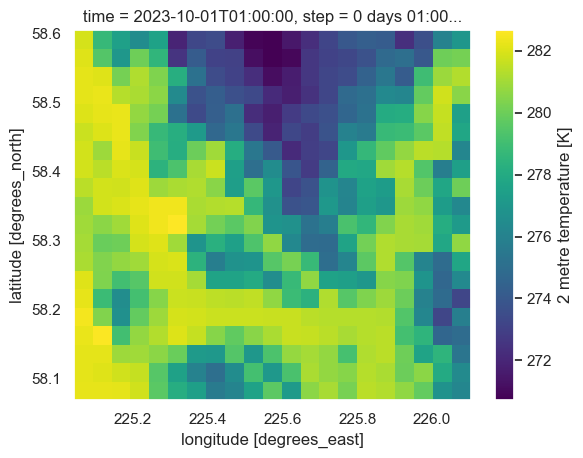

In [24]:
final_ds['temp'][0].plot()

For now, let's process 2025 the same way, then move to a cleaning script.

In [ ]:
# Define main folder path
folderspath = '/hdd/snow_hydrology/hrrrak/small_juneau_domain/WY2025'

# List all date folders
date_folders = sorted([f for f in os.listdir(folderspath) if f.startswith("hrrr.")])

def process_grib_file(grib_path):
    """ Process a single .grib2 file and return an xarray dataset """
    try:
        ds_subsets = cfgrib.open_datasets(grib_path)

        if len(ds_subsets) < 3:
            print(f"⚠️ Skipping {grib_path}: Expected at least 3 sub-datasets but found {len(ds_subsets)}")
            return None

        ds_10m = ds_subsets[0].drop_vars('heightAboveGround', errors='ignore')
        ds_2m = ds_subsets[1].drop_vars('heightAboveGround', errors='ignore')
        ds_0m = ds_subsets[2].assign_coords({'heightAboveGround': 0.0}).drop_vars('heightAboveGround', errors='ignore')

        ds_merged = xr.merge([ds_0m, ds_2m, ds_10m])

        # Calculate wind speed
        ds_merged['wind'] = np.sqrt(ds_merged['u10']**2 + ds_merged['v10']**2)
        ds_merged['wind'].attrs.update({
            'long_name': '10 metre wind speed calculated from u and v wind components',
            'GRIB_shortName': '10m wind',
            'standard_name': 'wind speed',
            'GRIB_name': '10 metre wind speed',
            'GRIB_cfName': 'wind_speed',
            'GRIB_cfVarName': 'wind10'
        })

        # Rename variables
        ds_merged = ds_merged.rename({
            't': 'temp_surface',
            'sp': 'pressure',
            't2m': 'temp',
            'r2': 'rh',
            'sdwe': 'swe',
            'sde': 'snowdepth',
            'sdswrf': 'swrad',
            'sdlwrf': 'lwrad',
            'tp': 'precip_total',
            'prate': 'precip_rate'
        })

        # Drop unnecessary variables
        drop_vars = [var for var in ['unknown', 'surface'] if var in ds_merged]
        ds_merged = ds_merged.drop_vars(drop_vars, errors='ignore')

        # Set valid_time as the main time coordinate
        ds_merged = ds_merged.assign_coords({'time': ds_merged.valid_time})

        return ds_merged

    except Exception as e:
        print(f"⚠️ Error processing {grib_path}: {e}")
        return None

# Function to process a date folder in parallel
def process_date_folder(date_folder):
    date_path = os.path.join(folderspath, date_folder)
    grib_files = sorted([os.path.join(date_path, f) for f in os.listdir(date_path) if f.endswith(".grib2")])

    with ProcessPoolExecutor() as executor:
        ds_list = list(filter(None, executor.map(process_grib_file, grib_files)))

    if ds_list:
        try:
            return xr.concat(ds_list, dim="time")
        except ValueError as e:
            print(f"⚠️ Skipping {date_folder} due to concatenation error: {e}")
            return None
    return None

# Process all date folders in parallel
with ProcessPoolExecutor() as executor:
    all_ds_list = list(filter(None, executor.map(process_date_folder, date_folders)))

# Merge all datasets across all days
if all_ds_list:
    final_ds = xr.concat(all_ds_list, dim="time")
    print("✅ Successfully merged all datasets!")

    # Save to NetCDF
    output_path = "/hdd/snow_hydrology/hrrrak/small_juneau_domain/netcdf/hrrrak_merged_grib_WY2025.nc"
    final_ds.to_netcdf(output_path)
    print(f"📁 Saved merged dataset to {output_path}")
else:
    print("⚠️ No valid datasets found.")

✅ Successfully merged all datasets!
📁 Saved merged dataset to /hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_WY2025.nc


In [ ]:
# load the netcdf 
# final_ds = xr.open_dataset(output_path)
# final_ds = xr.open_dataset('/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_WY2025.nc') # load this instead if we want to work with the data but not run the script above again 

# Now assign the CRS with EPSG:4326 (assuming the lat/lon are in degrees)
final_ds.rio.write_crs("EPSG:4326", inplace=True)

### Move to script `2_clean_hrrrak_netcdf.ipynb` to, 
* clean up the CRS, select the point for the sites, and save new netcdfs